# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-18 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-18 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import sys
import os
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all, 1=info, 2=warning, 3=error

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.resnet_utils import build_resnet18, DropoutRateScheduler
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

2025-04-10 15:42:30.829931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744296150.850688   26876 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744296150.855924   26876 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Core Variables

In [2]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Path variables
DATA_PATH = '../data/'
OUTPUT_PATH = '../output/'
MODEL_PATH = OUTPUT_PATH + 'models/'
MODEL_NAME = 'resnet_18'  # Name of the model to be saved
LOG_PATH = OUTPUT_PATH + 'logs/'+ MODEL_NAME + '_info.json'  # Path to save model metrics

# Ensure directories exist
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

In [3]:
# Training parameters
BATCH_SIZE = 32  # + 64 and 128
EPOCHS = 10
LEARNING_RATE = 0.001

# Dropout parameters
DROPOUT_MODE = "fixed"  # or "custom_scheduler"
DROPOUT_RATE = 0.5  # fixed dropout rate
DROPOUT_RATE_START = 0.5  # starting rate for scheduler
DROPOUT_RATE_END = 0.3  # ending rate for scheduler

# Model selection parameters
MODE = 'max'
CHOSEN_METRIC = 'val_AUC'  # Metric to be used for model selection

# Final model path
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_pneumonia_model.keras'

# Create model logger
logger = ModelLogger()

# Data Loading & Preprocessing

In [4]:
train_images, train_labels, test_images, test_labels, val_images, val_labels = load_and_preprocess_data(
    DATA_PATH, seed=RANDOM_SEED
)


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# ResNet-18 Model

## Creation & Compilation

In [5]:
# Initialize model info for logging
model_info = {
    "model_name": MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "dropout_mode": DROPOUT_MODE,
    "dropout_rate": DROPOUT_RATE if DROPOUT_MODE == "fixed" else None,
    "dropout_start": DROPOUT_RATE_START if DROPOUT_MODE == "custom_scheduler" else None,
    "dropout_end": DROPOUT_RATE_END if DROPOUT_MODE == "custom_scheduler" else None,
    "random_seed": RANDOM_SEED
}

# Initialize logger with model info
logger.initialize_run(model_info)

In [ ]:
# Set random seeds for reproducibility
tf.random.set_seed(RANDOM_SEED)

# Create and compile model
if DROPOUT_MODE == "fixed":
    model = build_resnet18(dropout_rate=DROPOUT_RATE)
else:  # custom scheduler
    model = build_resnet18(dropout_rate=DROPOUT_RATE_START)
    
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

I0000 00:00:1744296155.117637   26876 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │     36,928 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ maxpool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 14, 14,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 14, 14,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 14, 14,    │        256 │ stage1_block2_co

 Total params: 11,183,106 (42.66 MB)

 Trainable params: 11,173,506 (42.62 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [7]:
# Create dropout scheduler if needed
if DROPOUT_MODE == "custom_scheduler":
    dropout_scheduler = DropoutRateScheduler(dropout_start=DROPOUT_RATE_START, dropout_end=DROPOUT_RATE_END, epochs=EPOCHS)

## Training

In [8]:
# Get callbacks
callbacks = get_callbacks(FINAL_MODEL_PATH, monitor=CHOSEN_METRIC, mode=MODE)

# Add dropout scheduler callback if using custom scheduler
if DROPOUT_MODE == "custom_scheduler":
    callbacks.append(dropout_scheduler)

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Train model
start_time = time.time()

history = train_model(
    model, 
    train_images, train_labels,
    val_images, val_labels,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=tf_verbosity
)

exec_time = round(time.time() - start_time, 2)
print(f"Model training completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

Epoch 1/10


I0000 00:00:1744296167.819427   26934 service.cc:148] XLA service 0x755da0017ad0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744296167.819448   26934 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce GTX 1650 Ti with Max-Q Design, Compute Capability 7.5
I0000 00:00:1744296169.643797   26934 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/148 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - AUC: 0.7576 - accuracy: 0.7083 - loss: 0.9770 

I0000 00:00:1744296180.177591   26934 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 ━━━━━━━━━━━━━━━━━━━━ 48s 163ms/step - AUC: 0.9459 - accuracy: 0.8896 - loss: 0.3903 - val_AUC: 0.8942 - val_accuracy: 0.7424 - val_loss: 1.2919 - learning_rate: 0.0010
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - AUC: 0.9904 - accuracy: 0.9524 - loss: 0.1269 - val_AUC: 0.8019 - val_accuracy: 0.7424 - val_loss: 1.4803 - learning_rate: 0.0010
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.9952 - accuracy: 0.9641 - loss: 0.0886 - val_AUC: 0.9464 - val_accuracy: 0.8760 - val_loss: 0.4149 - learning_rate: 0.0010
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - AUC: 0.9959 - accuracy: 0.9682 - loss: 0.0783 - val_AUC: 0.9748 - val_accuracy: 0.9256 - val_loss: 0.1995 - learning_rate: 0.0010
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.9976 - accuracy: 0.9719 - loss: 0.0633 - val_AUC: 0.9858 - val_accuracy: 0.9542 - val_loss: 0.1670 - learning_rate: 0.0010
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - AUC: 0.9983 - accuracy: 0.976

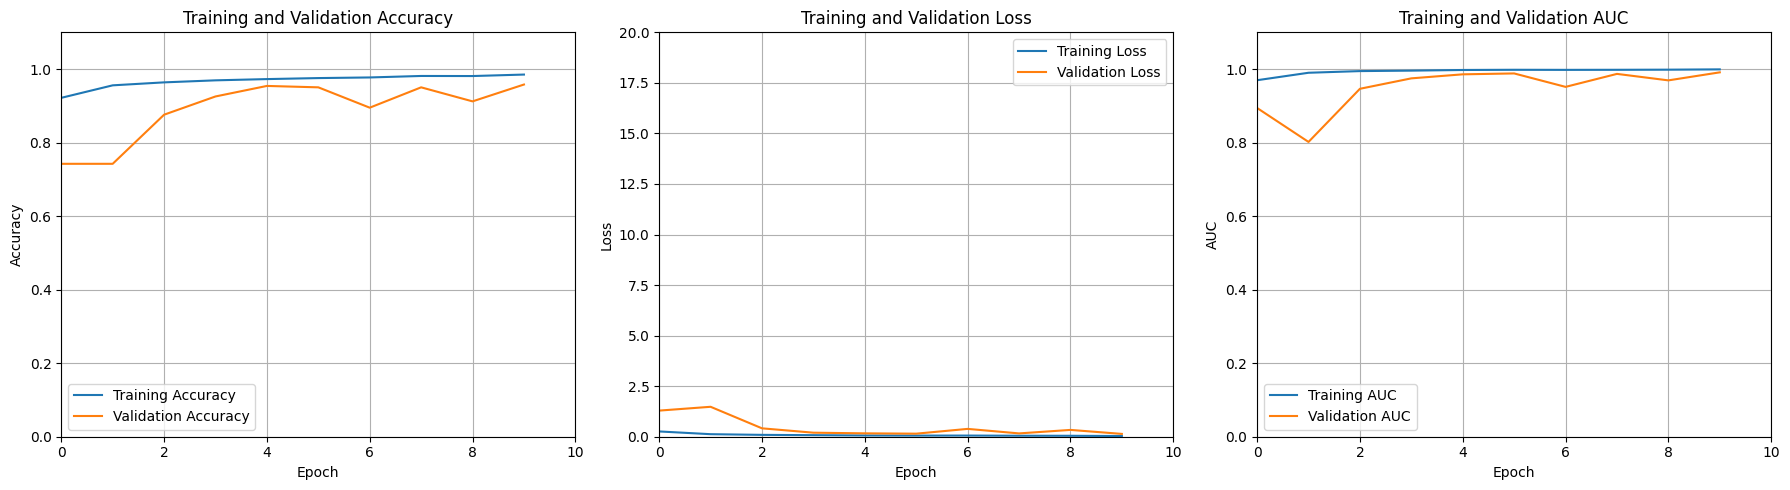

In [9]:
# Plot training history
plot_training_history(history, epochs=EPOCHS)

## Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - AUC: 0.9253 - accuracy: 0.8721 - loss: 0.6646
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step


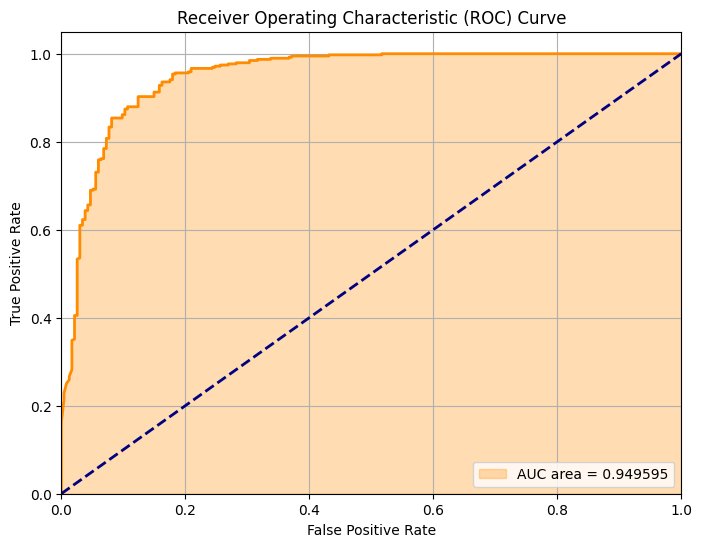

ROC AUC Score: 0.9496


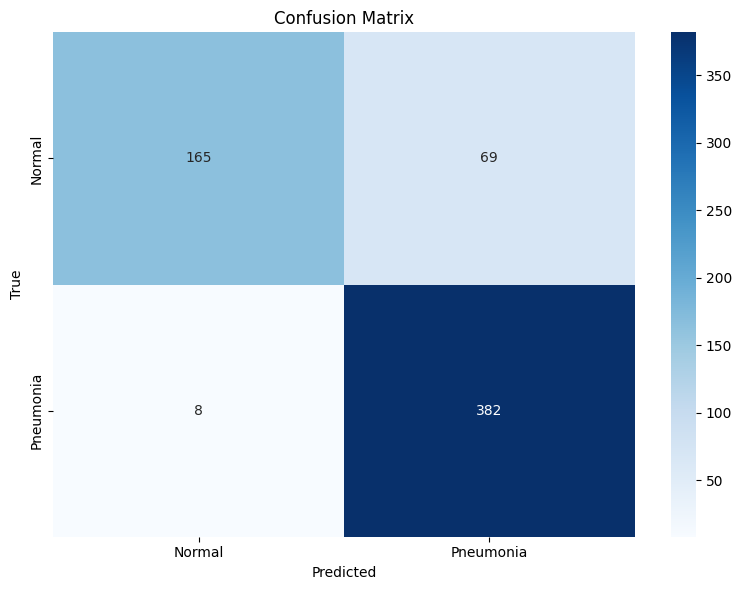

              precision    recall  f1-score   support

      Normal       0.95      0.71      0.81       234
   Pneumonia       0.85      0.98      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.89      0.88      0.87       624



In [10]:
# Evaluate model with reduced verbosity
results = evaluate_model(model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

## Save Model Information

In [12]:
# Save all model information
logger.save(LOG_PATH)

# Save final model
model.save(FINAL_MODEL_PATH)
print(f"Model saved to {FINAL_MODEL_PATH}")

Run information saved to ../output/logs/resnet_18_info.json
Model saved to ../output/models/resnet_18_b32_lr0.001_pneumonia_model.keras
